# Comparing Blink Detection by Eyelink vs. Algorithm by Hershman et al.

Reference: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

Reading ASC file data/sub001.asc:   0%|          | 0/172262 [00:00<?, ?it/s]

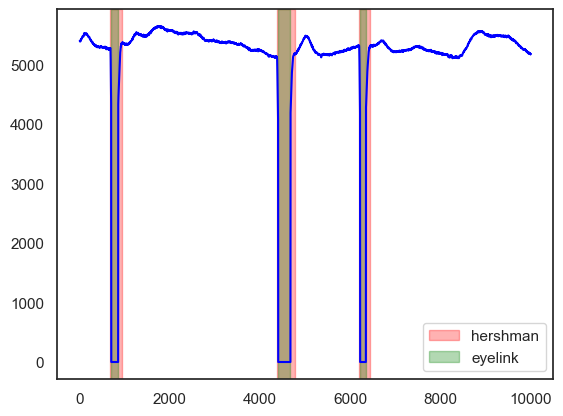

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pupeyes as pe

sns.set_theme('notebook', style='white')

# file name
path = 'data/sub001.asc'

# event marker format, specified as a dictionary {name: data type}   
msg_format = {'marker':str, 'event':str, 'block':str, 'trial':int} # e.g., start retention A 4
delimiter = ' ' # delimiter for messages

# start and stop notations for each trial
start_msg = 'start fixation'
stop_msg = 'end feedback'

# If you have any constant columns that you want to add
add_cols = {'subject':'sub001', 'condition': 'low'}

# read data
raw = pe.EyelinkReader(path=path, 
                       start_msg=start_msg, 
                       stop_msg=stop_msg, 
                       msg_format=msg_format, 
                       delimiter=delimiter, 
                       add_cols=add_cols
                       )
trial_idx = 2
samples = raw.get_samples()
samples = samples[samples.trial==trial_idx].reset_index(drop=True).iloc[0:10000] # just get a small part of the data

# get eyelink blinks
blinks_eyelink = raw.get_blinks()
blinks_eyelink = blinks_eyelink[blinks_eyelink.trial==trial_idx].reset_index(drop=True)


# get hershman blinks
from pupeyes.external.based_noise_blinks_detection import based_noise_blinks_detection
blinks_hershman = based_noise_blinks_detection(samples.pp, sampling_freq=1000)
blinks_hershman = pd.DataFrame(blinks_hershman)

# plot blinks
fig, ax = plt.subplots()
t = range(len(samples)) # normalize time to start at 0
ax.plot(t, samples.pp, color='blue')

for i, row in blinks_hershman.iterrows():
    hershman_onset = row['blink_onset']
    hershman_offset = row['blink_offset']
    if i == 0:
        ax.axvspan(samples.trackertime[hershman_onset]-samples.trackertime[0], samples.trackertime[hershman_offset]-samples.trackertime[0], color='red', alpha=0.3, label='hershman')
    else:
        ax.axvspan(samples.trackertime[hershman_onset]-samples.trackertime[0], samples.trackertime[hershman_offset]-samples.trackertime[0], color='red', alpha=0.3)

for i, row in blinks_eyelink.iterrows():
    blink_onset = row['starttime']
    blink_offset = row['endtime']
    if i == 0:
        ax.axvspan(blink_onset-samples.trackertime[0], blink_offset-samples.trackertime[0], color='green', alpha=0.3, label='eyelink')
    else:
        ax.axvspan(blink_onset-samples.trackertime[0], blink_offset-samples.trackertime[0], color='green', alpha=0.3)

ax.legend()